In [1]:
file_read = "004_fit_MPAA"
file_write = "005_RMSE_MPAA"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

In [4]:
df_train_val_preds = df_train_val_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [5]:
df_train_val_preds

backbone_test,n_features,backbone,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,51,1,0,0.061619,-0.040063,51.539999,48.99855
0,51,2,0,-0.086761,-0.124646,47.832328,46.887872
0,51,3,0,-0.086245,-0.133633,47.845209,46.664137
0,51,4,0,-0.242775,-0.071166,43.960253,48.221597
0,51,5,0,0.146419,0.168976,53.653941,54.214366
…,…,…,…,…,…,…,…
20,5,2,12,-0.175969,-0.006847,45.612098,49.828828
20,5,3,12,-0.155744,-0.024603,46.114252,49.384961
20,5,4,12,-0.010116,-0.045893,49.74711,48.852868


In [6]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [7]:
df_train_val_rmse

n_features,beta_av_rmse
i32,f64
51,6.417016
50,6.403717
49,6.403694
48,6.306392
47,6.305009
…,…
9,4.689776
8,4.708157
7,4.784151


In [8]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [9]:
df_train_val_rmse_min

n_features,beta_av_rmse
i32,f64
9,4.689776


In [10]:
n_features_min = df_train_val_rmse_min["n_features"][0]

In [11]:
df_test_preds = df_test_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [12]:
df_test_preds

backbone_test,n_features,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,51,0,0.055549,-0.444219,51.388357,39.073624
0,51,1,0.56851,-0.156845,63.841924,46.086895
0,51,2,0.367487,-0.141776,59.085161,46.46153
0,51,3,0.122542,-0.072794,53.059721,48.180949
0,51,4,0.157034,-0.209481,53.917807,44.782043
…,…,…,…,…,…,…
20,5,8,-1.435257,-0.026736,19.228094,49.331636
20,5,9,-1.120282,0.050036,24.595903,51.250651
20,5,10,-1.321297,0.12567,21.060263,53.137618


In [13]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [14]:
df_test_rmse

n_features,beta_av_rmse
i32,f64
51,12.834644
50,12.834398
49,12.835572
48,12.833692
47,12.841004
…,…
9,12.744916
8,12.848182
7,12.278198


In [15]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [16]:
df_test_rmse_min

n_features,beta_av_rmse
i32,f64
9,12.744916


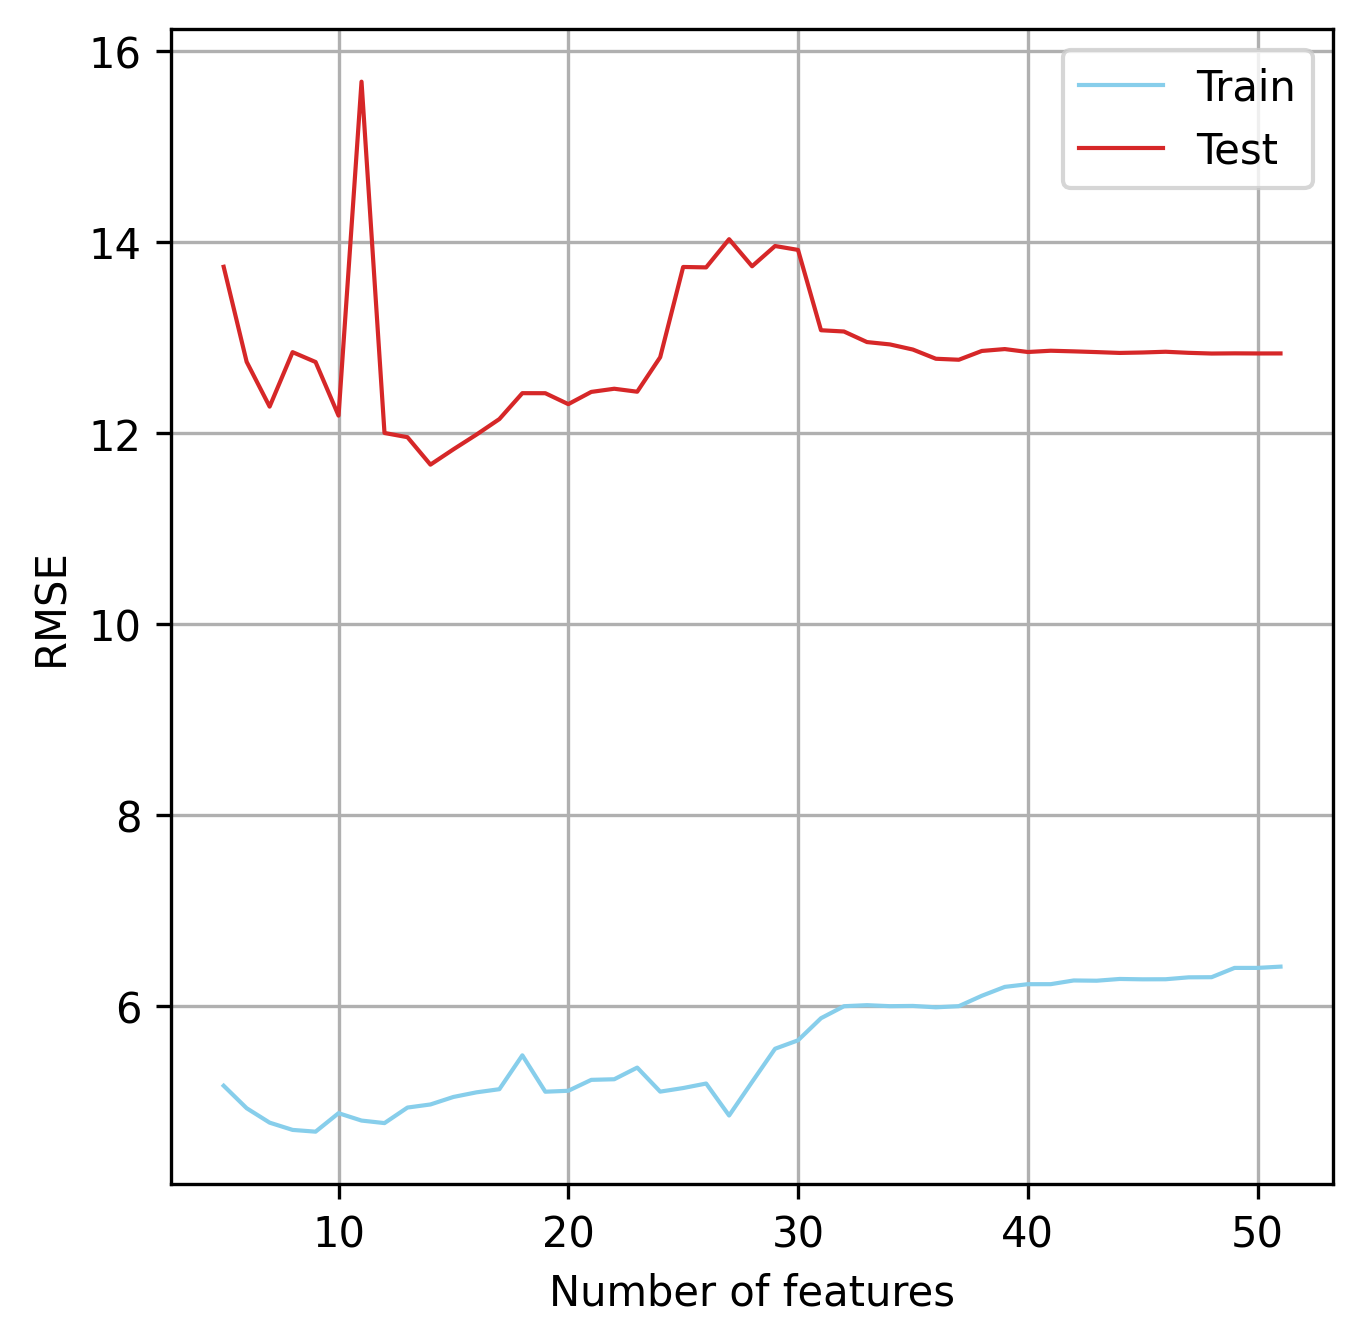

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [18]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [19]:
df_train_val_min

backbone_test,n_features,backbone,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,9,1,0,0.061619,0.011483,51.539999,50.287077
0,9,2,0,-0.086761,-0.140729,47.832328,46.487558
0,9,3,0,-0.086245,-0.070446,47.845209,48.239588
0,9,4,0,-0.242775,-0.108471,43.960253,47.290874
0,9,5,0,0.146419,0.23237,53.653941,55.78324
…,…,…,…,…,…,…,…
20,9,2,12,-0.175969,-0.042359,45.612098,48.941193
20,9,3,12,-0.155744,-0.018724,46.114252,49.531919
20,9,4,12,-0.010116,-0.043724,49.74711,48.907064


In [20]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [21]:
df_test_min

backbone_test,n_features,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,9,0,0.055549,-0.230361,51.388357,44.266305
0,9,1,0.56851,0.031313,63.841924,50.782772
0,9,2,0.367487,0.235563,59.085161,55.862005
0,9,3,0.122542,0.019265,53.059721,50.481615
0,9,4,0.157034,0.144914,53.917807,53.616525
…,…,…,…,…,…,…
20,9,8,-1.435257,-0.093081,19.228094,47.674665
20,9,9,-1.120282,-0.014188,24.595903,49.645318
20,9,10,-1.321297,-0.086033,21.060263,47.850496


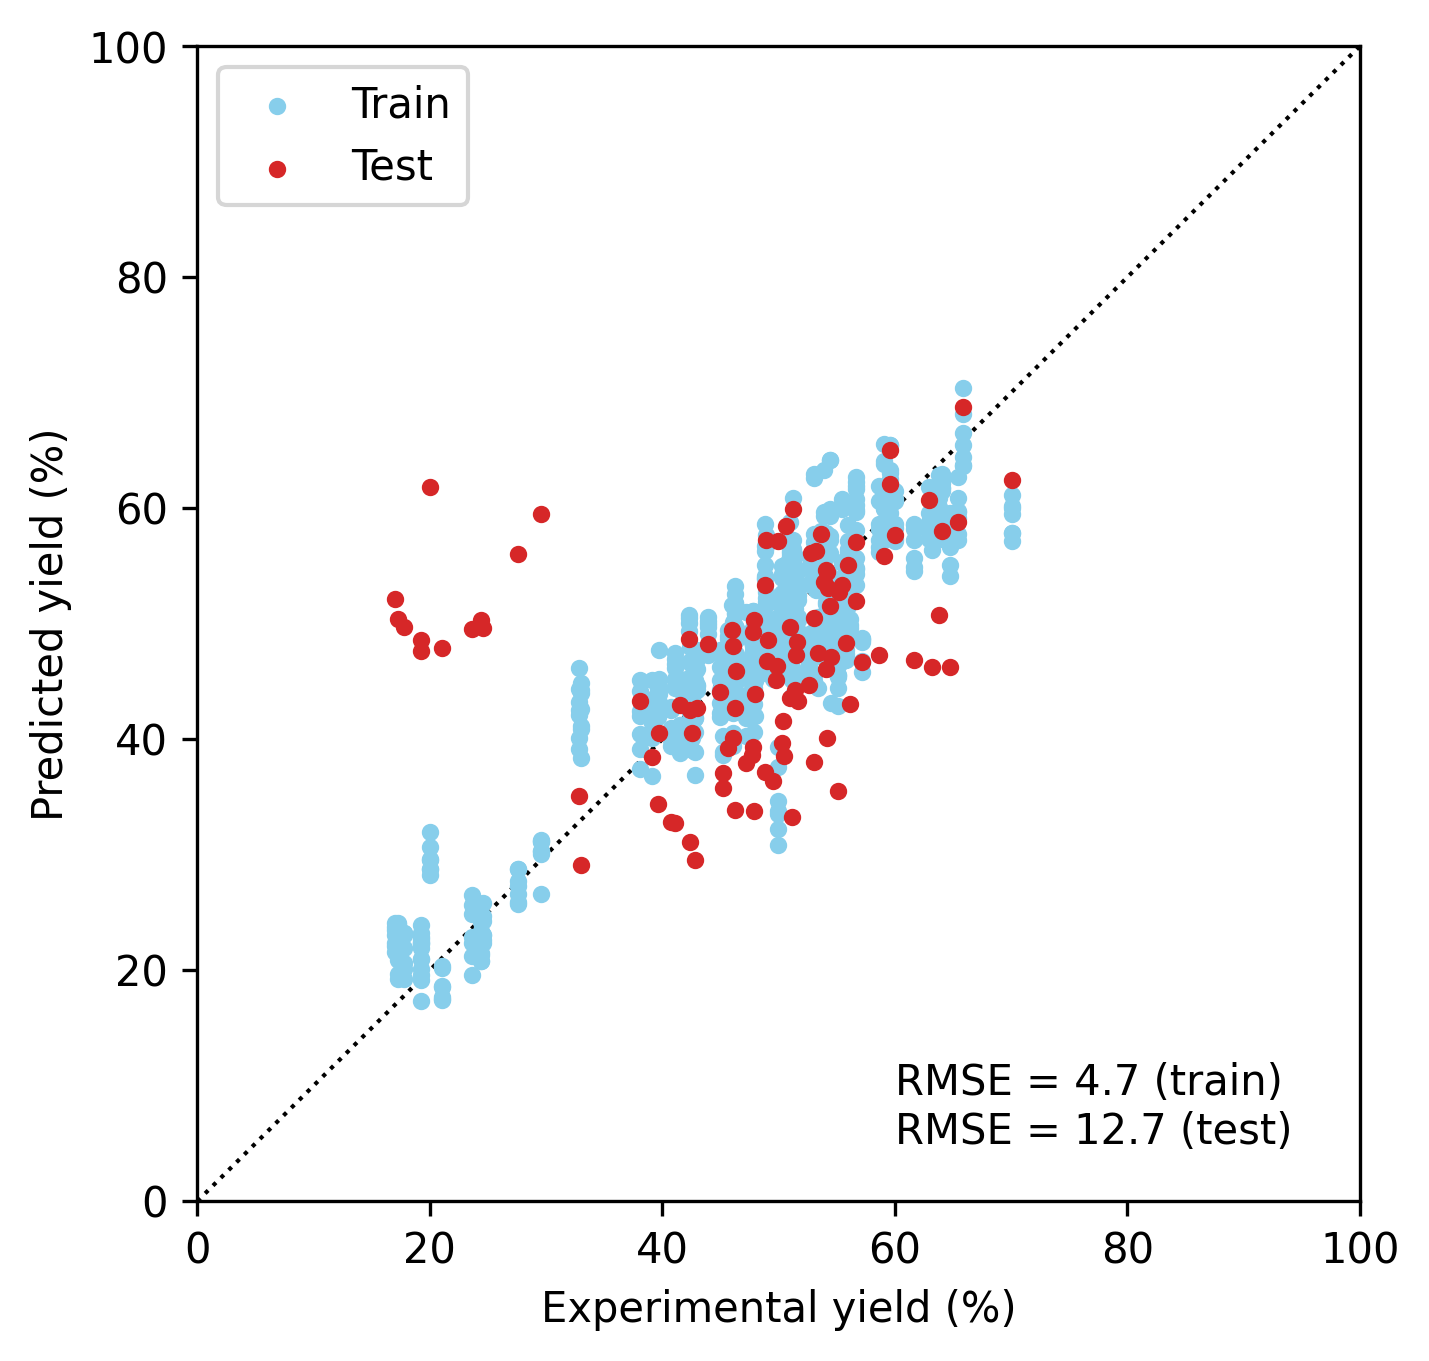

In [22]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental yield (%)")
ax.set_ylabel("Predicted yield (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.1f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.1f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [23]:
column_group = "backbone"

In [24]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [25]:
groups_test

backbone_test
i32
0
1
2
3
4
5
19
20


In [26]:
df_train_val_min

backbone_test,n_features,backbone,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,9,1,0,0.061619,0.011483,51.539999,50.287077
0,9,2,0,-0.086761,-0.140729,47.832328,46.487558
0,9,3,0,-0.086245,-0.070446,47.845209,48.239588
0,9,4,0,-0.242775,-0.108471,43.960253,47.290874
0,9,5,0,0.146419,0.23237,53.653941,55.78324
…,…,…,…,…,…,…,…
20,9,2,12,-0.175969,-0.042359,45.612098,48.941193
20,9,3,12,-0.155744,-0.018724,46.114252,49.531919
20,9,4,12,-0.010116,-0.043724,49.74711,48.907064


In [27]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [28]:
df_train_val_min_rmse

backbone_test,beta_av_rmse
i32,f64
0,4.954027
1,5.307259
2,5.369381
3,4.573287
4,4.269032
5,4.80388
19,4.075617
20,3.947771


In [29]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [30]:
df_test_min_rmse

backbone_test,beta_av_rmse
i32,f64
0,8.954363
1,4.609034
2,10.935907
3,4.624355
4,4.868648
5,4.367128
19,12.319759
20,29.368497


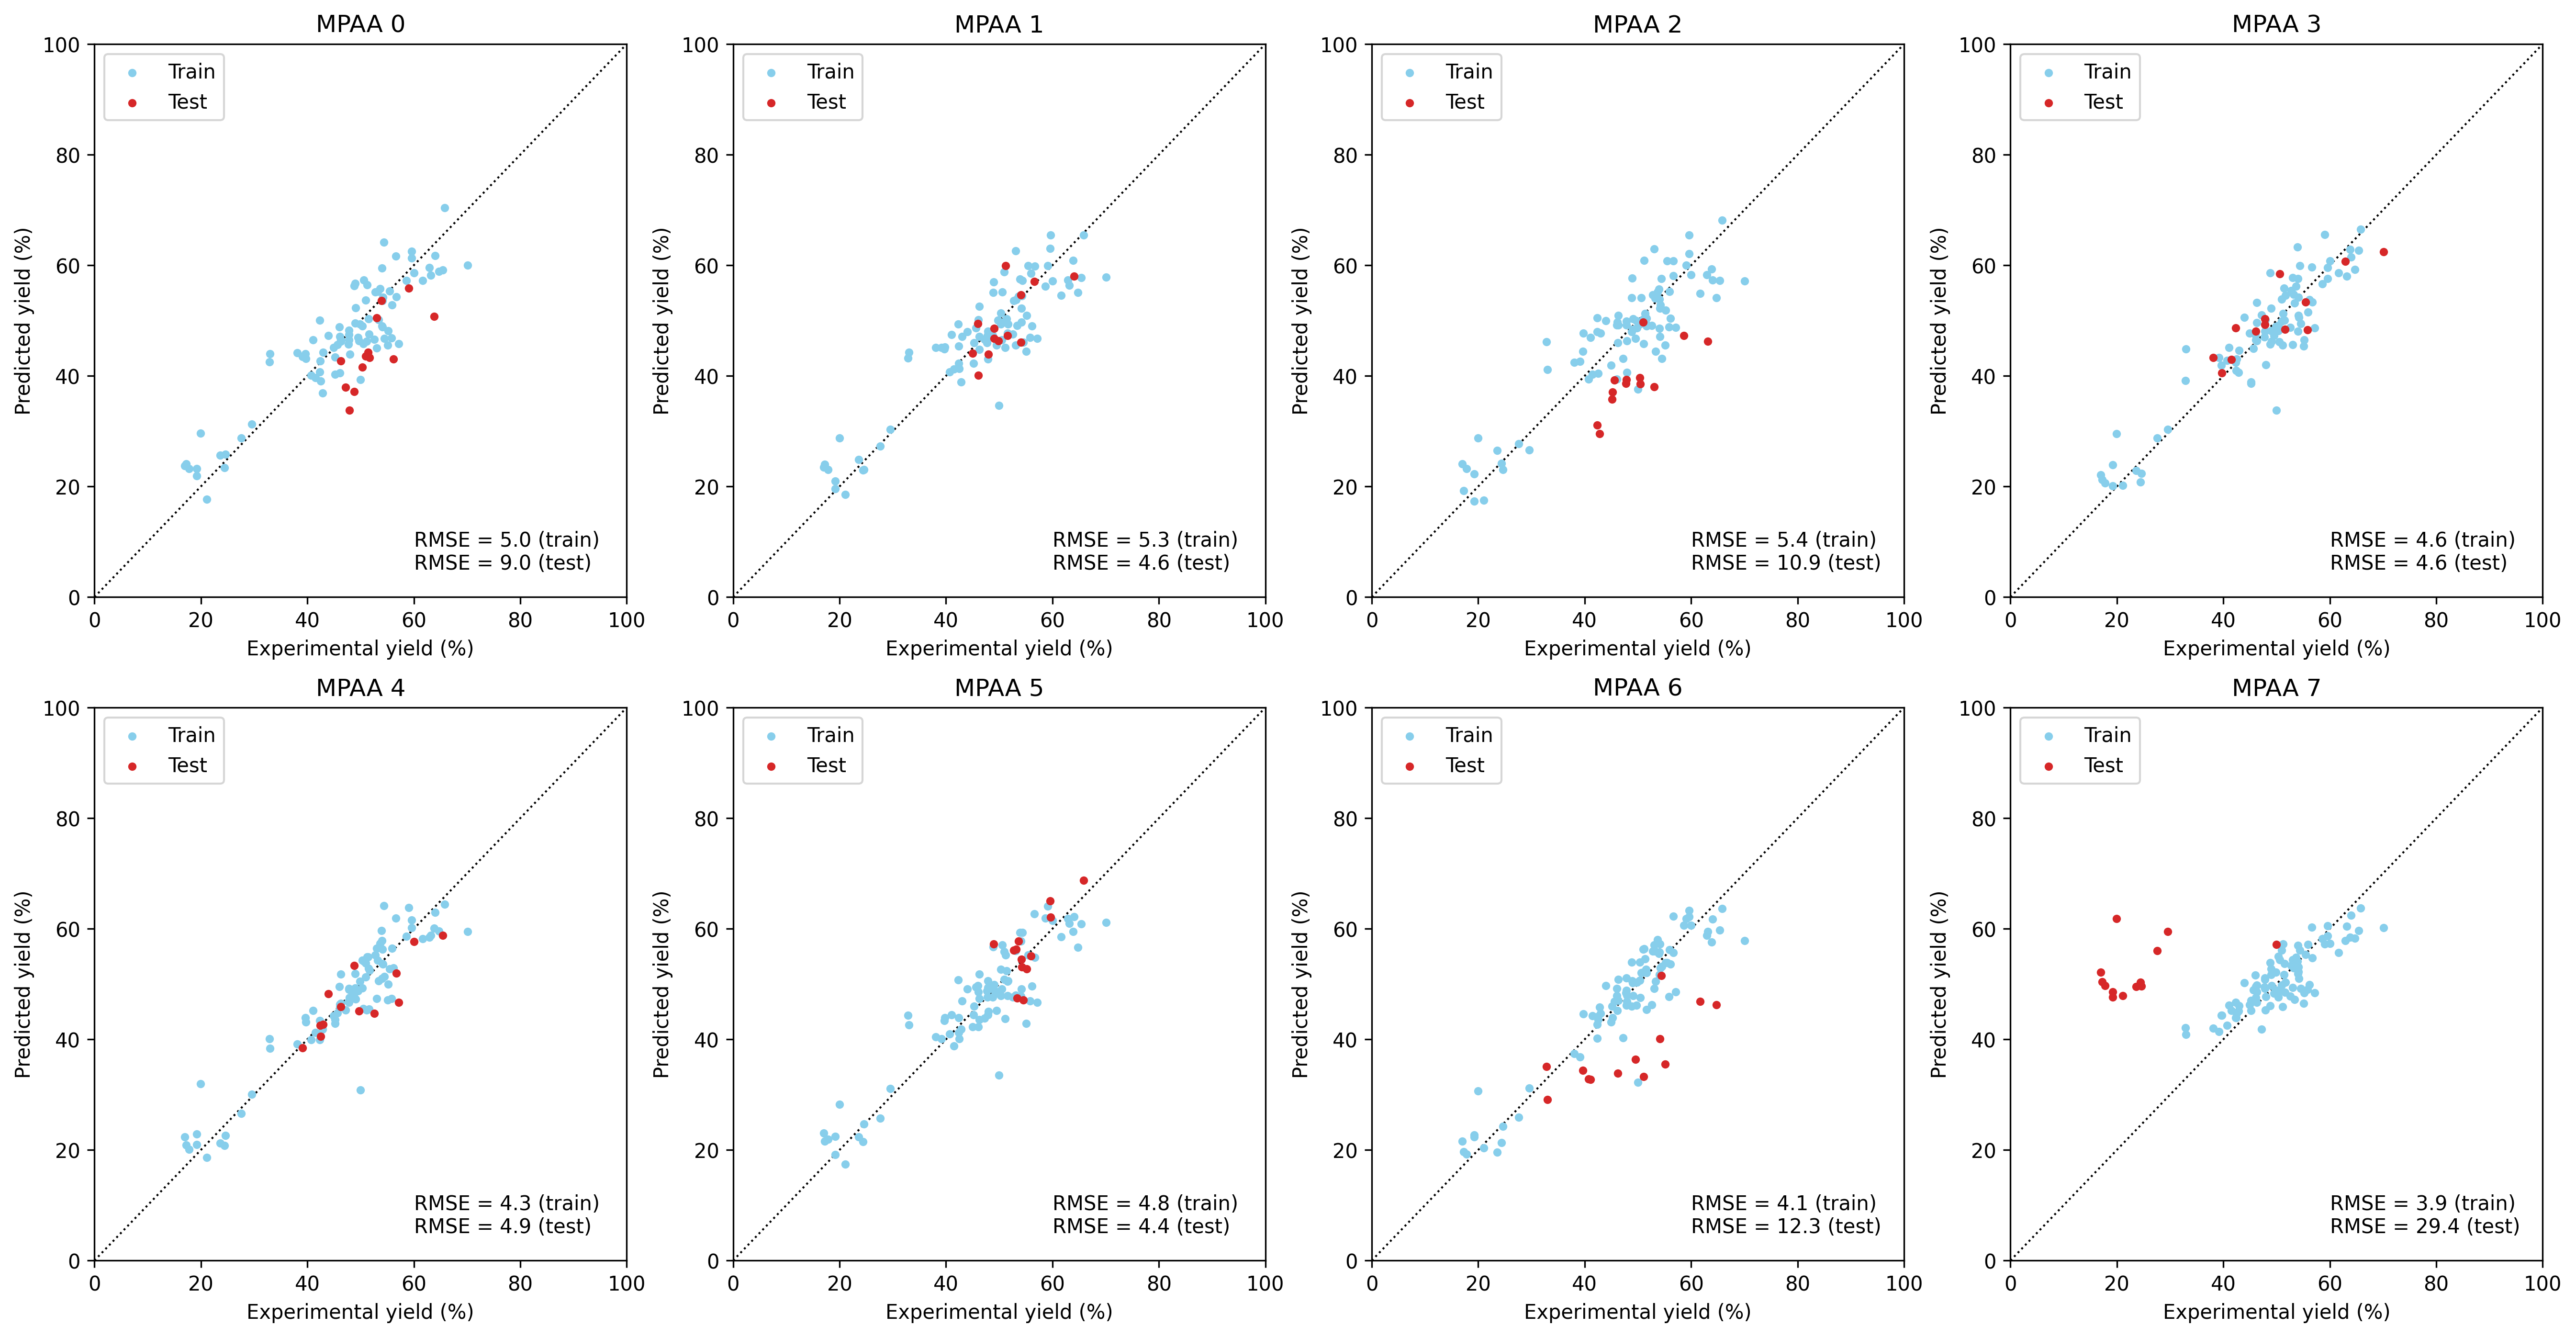

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    if group_test == 19:
        group_test = 6
    elif group_test == 20:
        group_test = 7
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"MPAA {group_test}")
    axes[div, mod].set_xlabel("Experimental yield (%)")
    axes[div, mod].set_ylabel("Predicted yield (%)")
    axes[div, mod].set_xlim(0, 100)
    axes[div, mod].set_ylim(0, 100)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()